In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/summer-analytics-mid-hackathon/hacktest.csv
/kaggle/input/summer-analytics-mid-hackathon/hacktrain.csv


In [2]:
import matplotlib.pyplot as plt

In [3]:
df_train = pd.read_csv('/kaggle/input/summer-analytics-mid-hackathon/hacktrain.csv')
df_test = pd.read_csv('/kaggle/input/summer-analytics-mid-hackathon/hacktest.csv')

In [4]:
df_train.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,Unnamed: 0,ID,class,20150720_N,20150602_N,20150517_N,20150501_N,20150415_N,20150330_N,20150314_N,...,20140610_N,20140525_N,20140509_N,20140423_N,20140407_N,20140322_N,20140218_N,20140202_N,20140117_N,20140101_N
0,0,1,water,637.5950,658.668,-1882.030,-1924.36,997.904,-1739.990,630.087,...,NaN,-1043.160,-1942.490,267.138,NaN,NaN,211.328,-2203.020,-1180.19,433.906
1,1,2,water,634.2400,593.705,-1625.790,-1672.32,914.198,-692.386,707.626,...,NaN,-933.934,-625.385,120.059,364.858,476.972,220.878,-2250.000,-1360.56,524.075
2,3,4,water,58.0174,-1599.160,NaN,-1052.63,NaN,-1564.630,NaN,...,-1025.88,368.622,NaN,-1227.800,304.621,NaN,369.214,-2202.120,NaN,-1343.550
3,4,5,water,72.5180,NaN,380.436,-1256.93,515.805,-1413.180,-802.942,...,-1813.95,155.624,NaN,-924.073,432.150,282.833,298.320,-2197.360,NaN,-826.727
4,7,8,water,1136.4400,NaN,NaN,1647.83,1935.800,NaN,2158.980,...,1535.00,1959.430,-279.317,-384.915,-113.406,1020.720,1660.650,-116.801,-568.05,-1357.140


In [5]:
df_train.shape

(8000, 30)

In [6]:
df_test.head()

,Unnamed: 0,ID,20150720_N,20150602_N,20150517_N,20150501_N,20150415_N,20150330_N,20150314_N,20150226_N,...,20140610_N,20140525_N,20140509_N,20140423_N,20140407_N,20140322_N,20140218_N,20140202_N,20140117_N,20140101_N
0,0,1,7466.42,413.162,5761.00,5625.45,489.403,3923.84,3097.110,6766.42,...,801.184,927.115,4704.14,6378.42,340.949,2695.570,527.268,4736.75,601.843,6639.760
1,1,2,7235.26,6037.350,1027.56,6085.14,1618.050,6668.54,2513.990,1051.69,...,5533.470,5103.040,5216.12,4885.27,4366.790,1234.140,3298.110,6942.68,1070.440,842.101
2,2,3,7425.08,6969.980,1177.94,7408.93,861.061,7644.43,814.458,1504.29,...,1981.390,6204.540,7021.69,5704.41,4897.450,1789.990,2206.100,6928.93,1036.560,831.441
3,3,4,7119.12,1731.620,6311.93,6441.61,465.979,7128.42,1649.120,6935.22,...,959.344,5794.150,1045.57,5572.90,586.287,685.906,1287.000,6734.72,824.584,6883.610
4,4,5,7519.55,8130.260,1482.54,7879.53,1001.210,7937.60,4122.530,1094.51,...,7636.070,6996.760,7413.43,4596.13,4511.700,1413.520,3283.940,7937.68,1857.800,1336.920


In [7]:
df_train.isna().sum()

Unnamed: 0       0
ID               0
class            0
20150720_N     560
20150602_N    1200
20150517_N     800
20150501_N     960
20150415_N     480
20150330_N    1120
20150314_N     720
20150226_N    1360
20150210_N     640
20150125_N    1040
20150109_N     880
20141117_N    1280
20141101_N     400
20141016_N    1440
20140930_N     800
20140813_N     560
20140626_N    1600
20140610_N     480
20140525_N     720
20140509_N     880
20140423_N    1760
20140407_N     640
20140322_N    1120
20140218_N    1440
20140202_N     560
20140117_N    1200
20140101_N     400
dtype: int64

In [8]:
df_test.isna().sum()

Unnamed: 0    0
ID            0
20150720_N    0
20150602_N    0
20150517_N    0
20150501_N    0
20150415_N    0
20150330_N    0
20150314_N    0
20150226_N    0
20150210_N    0
20150125_N    0
20150109_N    0
20141117_N    0
20141101_N    0
20141016_N    0
20140930_N    0
20140813_N    0
20140626_N    0
20140610_N    0
20140525_N    0
20140509_N    0
20140423_N    0
20140407_N    0
20140322_N    0
20140218_N    0
20140202_N    0
20140117_N    0
20140101_N    0
dtype: int64

In [9]:
df_train.drop(columns=['Unnamed: 0', 'ID'], inplace=True)

In [10]:
df_train.describe()

,20150720_N,20150602_N,20150517_N,20150501_N,20150415_N,20150330_N,20150314_N,20150226_N,20150210_N,20150125_N,...,20140610_N,20140525_N,20140509_N,20140423_N,20140407_N,20140322_N,20140218_N,20140202_N,20140117_N,20140101_N
count,7440.000000,6800.000000,7200.000000,7040.000000,7520.000000,6880.000000,7280.000000,6640.000000,7360.000000,6960.000000,...,7520.000000,7280.000000,7120.000000,6240.000000,7360.000000,6880.000000,6560.000000,7440.000000,6800.000000,7600.000000
mean,5845.476916,4868.091395,4469.837748,5193.485086,2927.586705,4924.493648,3313.881373,4987.520158,4320.961814,5237.037739,...,4872.681670,3674.886731,3012.178524,3055.167358,2041.316792,2799.820342,2144.360224,6259.064275,2629.203972,2578.449870
std,2261.409128,2758.499942,2876.218394,2510.389832,2728.325670,2600.418802,2434.828743,2674.963286,2807.501097,2762.489857,...,2776.135418,2331.105635,2068.334108,2209.985887,2040.354512,2452.563243,2267.606759,1825.563702,2386.147667,2436.270797
min,-433.735000,-1781.790000,-2939.740000,-1924.360000,-1794.870000,-1848.910000,-1574.970000,-2532.490000,-3403.050000,-2849.860000,...,-2683.600000,-1043.160000,-2435.900000,-1505.780000,-1445.370000,55.564100,-232.292000,-2729.430000,-2139.860000,-4145.250000
25%,4331.232500,2067.265000,1521.195000,3087.072500,500.515750,2398.385000,992.778250,2404.075000,1377.927500,2638.000000,...,2010.732500,1369.355000,1368.742500,1009.827500,419.987000,791.741250,501.602750,5938.257500,691.171500,689.199000
50%,6908.255000,5513.375000,4672.000000,5810.755000,1586.240000,5742.485000,2802.010000,5831.120000,4497.485000,6518.745000,...,5484.905000,3659.770000,2633.695000,2624.125000,1183.715000,1599.385000,969.711500,6941.010000,1521.210000,1439.950000
75%,7626.845000,7555.570000,7431.697500,7511.880000,5703.067500,7280.110000,5508.350000,7430.915000,7217.497500,7585.817500,...,7607.755000,5927.035000,4128.082500,4952.317500,3075.997500,4909.997500,3227.380000,7395.612500,4452.257500,4146.342500
max,8376.150000,8566.420000,8650.500000,8516.100000,8267.120000,8499.330000,8001.700000,8452.380000,8422.060000,8401.100000,...,8489.970000,7981.820000,8445.410000,7762.980000,8078.080000,8216.700000,8247.630000,8410.330000,8418.230000,8502.020000


In [11]:
import seaborn as sns

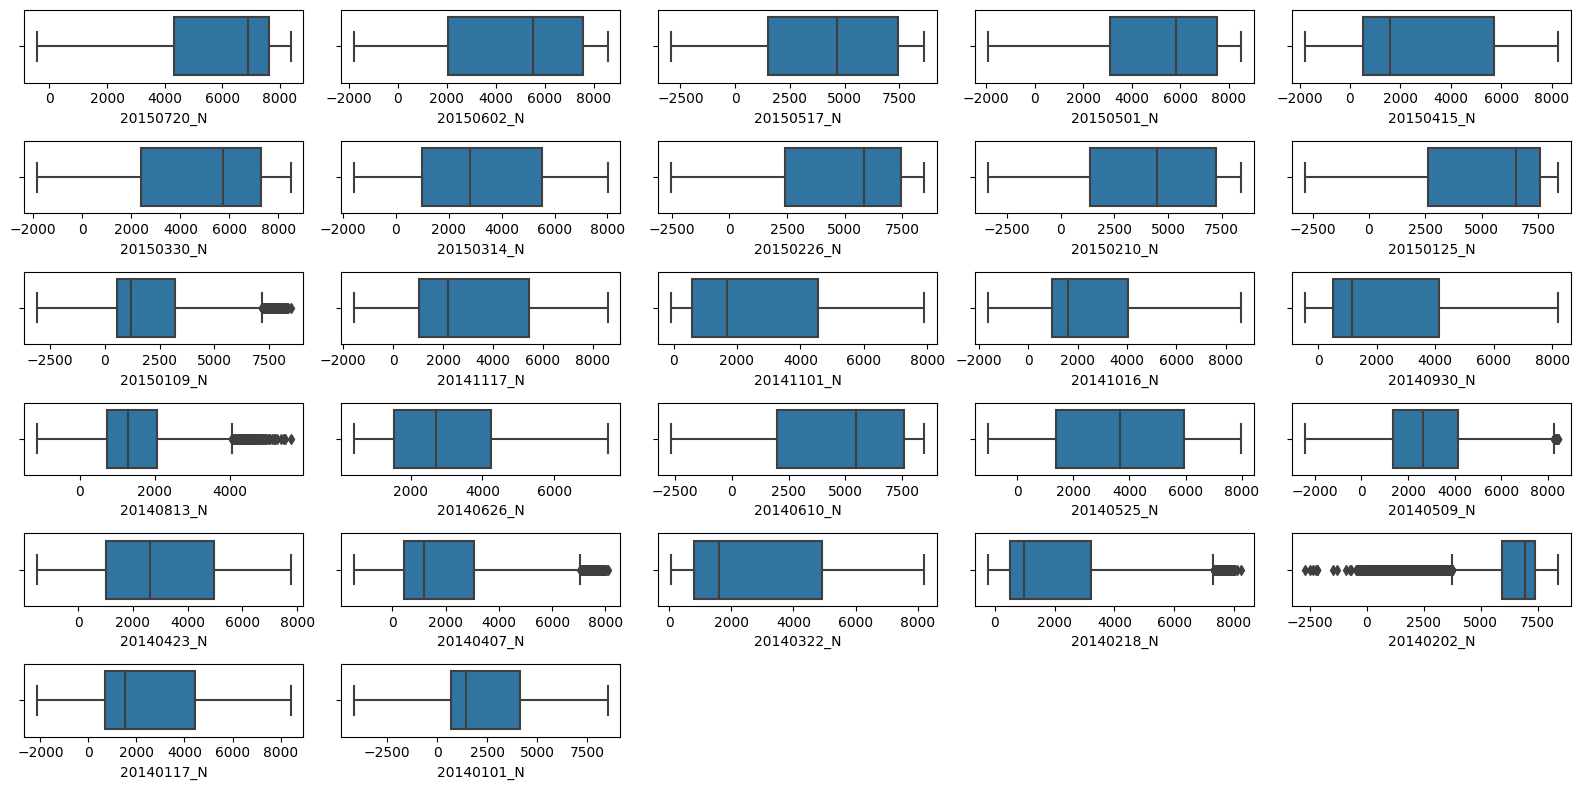

In [12]:
array = df_train.drop(columns=['class']).columns
plt.figure(figsize=(16,8))
for i in range(len(array)):
  plt.subplot(6,5,(i+1))
  sns.boxplot(data=df_train, x=f'{array[i]}')

plt.tight_layout()
plt.show()

In [13]:
df_train.fillna(df_train.mean(numeric_only=True), inplace=True)

In [14]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   class       8000 non-null   object 
 1   20150720_N  8000 non-null   float64
 2   20150602_N  8000 non-null   float64
 3   20150517_N  8000 non-null   float64
 4   20150501_N  8000 non-null   float64
 5   20150415_N  8000 non-null   float64
 6   20150330_N  8000 non-null   float64
 7   20150314_N  8000 non-null   float64
 8   20150226_N  8000 non-null   float64
 9   20150210_N  8000 non-null   float64
 10  20150125_N  8000 non-null   float64
 11  20150109_N  8000 non-null   float64
 12  20141117_N  8000 non-null   float64
 13  20141101_N  8000 non-null   float64
 14  20141016_N  8000 non-null   float64
 15  20140930_N  8000 non-null   float64
 16  20140813_N  8000 non-null   float64
 17  20140626_N  8000 non-null   float64
 18  20140610_N  8000 non-null   float64
 19  20140525_N  8000 non-null  

In [15]:
df_train['class'].unique()

array(['water', 'forest', 'impervious', 'farm', 'grass', 'orchard'],
      dtype=object)

In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_train['class'])
df_train['class'] = y_encoded

In [17]:
df_train['class'].unique()

array([5, 1, 3, 0, 2, 4])

In [18]:
df_test.drop(columns=['ID', 'Unnamed: 0'], inplace=True)

In [19]:
df_test.columns

Index(['20150720_N', '20150602_N', '20150517_N', '20150501_N', '20150415_N',
       '20150330_N', '20150314_N', '20150226_N', '20150210_N', '20150125_N',
       '20150109_N', '20141117_N', '20141101_N', '20141016_N', '20140930_N',
       '20140813_N', '20140626_N', '20140610_N', '20140525_N', '20140509_N',
       '20140423_N', '20140407_N', '20140322_N', '20140218_N', '20140202_N',
       '20140117_N', '20140101_N'],
      dtype='object')

In [20]:
X_test = df_test

In [21]:
X = df_train.drop(columns=['class'])
y = df_train['class']

In [22]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# y_scaler = StandardScaler()
# X[X.columns] = scaler.fit_transform(X)
# X_test[X_test.columns] = scaler.transform(X_test)

In [23]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
y_scaler = RobustScaler()
X[X.columns] = scaler.fit_transform(X)
X_test[X_test.columns] = scaler.transform(X_test)

In [23]:
from sklearn.linear_model import LogisticRegression

In [35]:
model = LogisticRegression(
    multi_class='multinomial',  
    solver='lbfgs',             
    max_iter=2000,              
    random_state=42
)

In [36]:
# Fit the model
model.fit(X, y)

LogisticRegression(max_iter=2000, multi_class='multinomial', random_state=42)

In [37]:
y_pred = model.predict(X_test)

In [38]:
y_pred

array([0, 1, 4, ..., 5, 5, 3])

In [39]:
y_decoded = label_encoder.inverse_transform(y_pred)

In [40]:
y_decoded

array(['farm', 'forest', 'orchard', ..., 'water', 'water', 'impervious'],
      dtype=object)

# # Using GridSearchCV

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Define the parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs'],                    
    'multi_class': ['multinomial'],      
    'class_weight': [None, 'balanced'],  
    'max_iter': [1000],                
    'penalty': ['l2']            
}

# Initialize the model
lr = LogisticRegression(random_state=42)

# GridSearch with 5-fold cross-validation
grid = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

In [26]:
# Fit to the training data
grid.fit(X, y)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'], 'max_iter': [1000],
                         'multi_class': ['multinomial'], 'penalty': ['l2'],
                         'solver': ['lbfgs']},
             scoring='f1_macro', verbose=1)

In [27]:
# Best parameters and model
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validated F1 Score:", grid.best_score_)

Best Parameters: {'C': 10, 'class_weight': None, 'max_iter': 1000, 'multi_class': 'multinomial', 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validated F1 Score: 0.504659758802698


In [28]:
# Predict and evaluate on test set
y_pred = grid.predict(X_test)

In [29]:
y_pred

array([0, 1, 4, ..., 5, 5, 3])

In [30]:
y_decoded = label_encoder.inverse_transform(y_pred)

In [31]:
y_decoded

array(['farm', 'forest', 'orchard', ..., 'water', 'water', 'impervious'],
      dtype=object)

In [32]:
df = pd.read_csv('/kaggle/input/summer-analytics-mid-hackathon/hacktest.csv')

In [33]:
ID=df['ID']

In [34]:
result = pd.DataFrame({
    'ID': ID,
    'class': y_decoded
})

In [35]:
result

,ID,class
0,1,farm
1,2,forest
2,3,orchard
3,4,forest
4,5,forest
...,...,...
2840,2841,water
2841,2842,impervious
2842,2843,water
2843,2844,water


In [36]:
result.to_csv('output3.csv', index=False)